In [ ]:
# spectral_shiftnmfk_tfgm_v12.py
import numpy as np
from typing import Optional, Tuple, Dict, Literal

# --------------------------
# Shift operators & helpers
# --------------------------
def circ_shift_linpos_1d(x: np.ndarray, tau: float) -> np.ndarray:
    """Circular, linear-interp shift by real-valued tau (nonnegative output)."""
    L = int(x.shape[0])
    if L == 0: return x.copy()
    k = int(np.floor(tau))
    a = float(tau - k)
    idx0 = (np.arange(L) - k) % L
    idx1 = (idx0 - 1) % L
    return (1.0 - a) * x[idx0] + a * x[idx1]

def vec_outer(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return np.outer(a, b).reshape(-1)

def xcorr_circ(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    A = np.fft.fft(a); B = np.fft.fft(b)
    return np.real(np.fft.ifft(np.conj(A)*B))

def argmax_local_circ(c: np.ndarray, center: float, window: int) -> float:
    L = c.size
    k0 = int(np.round(np.mod(center, L)))
    idx = (k0 + np.arange(-window, window+1)) % L
    j = idx[int(np.argmax(c[idx]))]
    jm1, jp1 = (j-1) % L, (j+1) % L
    y_m1, y0, y_p1 = c[jm1], c[j], c[jp1]
    denom = (y_m1 - 2*y0 + y_p1)
    delta = 0.0 if abs(denom) < 1e-12 else 0.5*(y_m1 - y_p1)/denom
    tau = (j + delta) % L
    if tau > L/2: tau -= L
    return float(tau)

# --------------------------
# The model (v12)
# --------------------------
class SpectralShiftNMFkTFGM:
    """
    X[n,f,t] ≈ sum_i W[n,i] * Fi_shifted_{n,i}[f] * Si_shifted_{n,i}[t]
    with Fi_shifted_{n,i} = circ_shift_linpos_1d(F[i], tau_f[n,i]) and same for S.

    v12 highlights:
      - W update = ridge LS, ≥0, **no column renorm** (amplitude preserved).
      - (F,S) update = **SVD rank-1** on weighted aligned residual, **keeps singular value** (amplitude),
        projects to ≥0, and **accepts only if the loss decreases**.
      - fit(mode=...) lets you pick "monolithic", "shifts_only", or "staged".
    """
    def __init__(
        self,
        K: int,
        n_iters: int = 400,
        freeze_tau_iters: int = 120,
        snap_every: int = 5,
        snap_window_f: int = 6,
        snap_window_t: int = 6,
        inner_rank1_iters: int = 1,     # one SVD per iter is enough
        ridge_w: float = 0.0,
        seed: Optional[int] = 0,
        verbose: bool = True,
        # staged-mode knobs:
        iters_w: int = 60,
        iters_fs: int = 120,
        iters_snap: int = 80,
        mode: Literal["monolithic","staged","shifts_only"] = "monolithic",
    ) -> None:
        self.K = int(K)
        self.n_iters = int(n_iters)
        self.freeze_tau_iters = int(freeze_tau_iters)
        self.snap_every = int(snap_every)
        self.snap_window_f = int(snap_window_f)
        self.snap_window_t = int(snap_window_t)
        self.inner_rank1_iters = int(inner_rank1_iters)
        self.ridge_w = float(ridge_w)
        self.rng = np.random.default_rng(seed)
        self.verbose = bool(verbose)
        self.iters_w = int(iters_w)
        self.iters_fs = int(iters_fs)
        self.iters_snap = int(iters_snap)
        self.mode = mode

        self.W = None   # (N,K)
        self.F = None   # (K,F)
        self.S = None   # (K,T)
        self.tau_f = None  # (N,K)
        self.tau_t = None  # (N,K)
        self.X = None
        self.loss_history = []

    # ---------- deterministic forward map ----------
    @staticmethod
    def reconstruct_from_params(W, F, S, tau_f, tau_t) -> np.ndarray:
        N,K = W.shape
        Fdim = F.shape[1]; Tdim = S.shape[1]
        X_hat = np.zeros((N,Fdim,Tdim), dtype=float)
        for n in range(N):
            for i in range(K):
                Fi = circ_shift_linpos_1d(F[i], float(tau_f[n,i]))
                Si = circ_shift_linpos_1d(S[i], float(tau_t[n,i]))
                X_hat[n] += W[n,i] * np.outer(Fi, Si)
        return X_hat

    # ---------- internal reconstruction ----------
    def _reconstruct_components(self):
        N, Fdim, Tdim = self.X.shape
        Fi_shifted = np.zeros((N, self.K, Fdim))
        Si_shifted = np.zeros((N, self.K, Tdim))
        for n in range(N):
            for i in range(self.K):
                Fi_shifted[n,i] = circ_shift_linpos_1d(self.F[i], self.tau_f[n,i])
                Si_shifted[n,i] = circ_shift_linpos_1d(self.S[i], self.tau_t[n,i])
        X_hat = np.zeros_like(self.X)
        for n in range(N):
            # sum_i W[n,i] * Fi ⊗ Si
            X_hat[n] = np.tensordot(
                self.W[n],
                np.einsum("if,it->ift", Fi_shifted[n], Si_shifted[n]),
                axes=(0,0)
            )
        return Fi_shifted, Si_shifted, X_hat

    # ---------- W update (ridge LS, ≥0, no renorm) ----------
    def _update_W_ls(self, Fi_shifted: np.ndarray, Si_shifted: np.ndarray) -> None:
        N,Fdim,Tdim = self.X.shape
        FT = Fdim*Tdim
        for n in range(N):
            A = np.stack(
                [vec_outer(Fi_shifted[n,i], Si_shifted[n,i]) for i in range(self.K)],
                axis=1
            )  # (FT,K)
            b = self.X[n].reshape(FT)
            AtA = A.T @ A
            if self.ridge_w > 0:
                AtA = AtA + self.ridge_w * np.eye(self.K)
            Atb = A.T @ b
            w = np.linalg.solve(AtA, Atb)
            self.W[n] = np.clip(w, 1e-12, None)

    # ---------- (F,S) update: SVD rank-1, amplitude preserved, accept-if-better ----------
    def _update_rank1_for_component(self, i: int) -> None:
        N,Fdim,Tdim = self.X.shape
        # 1) Shift dict once
        Fi_shifted = np.zeros((N, self.K, Fdim))
        Si_shifted = np.zeros((N, self.K, Tdim))
        for n in range(N):
            for k in range(self.K):
                Fi_shifted[n,k] = circ_shift_linpos_1d(self.F[k], self.tau_f[n,k])
                Si_shifted[n,k] = circ_shift_linpos_1d(self.S[k], self.tau_t[n,k])
        # 2) Residual excl i
        R_i = np.zeros((N,Fdim,Tdim))
        for n in range(N):
            recon_wo_i = np.zeros((Fdim,Tdim))
            for j in range(self.K):
                if j == i: continue
                recon_wo_i += self.W[n,j] * np.outer(Fi_shifted[n,j], Si_shifted[n,j])
            R_i[n] = self.X[n] - recon_wo_i
        # 3) Weighted, aligned residual
        w = self.W[:,i]; wsum = float(np.sum(w))
        if wsum <= 1e-16: return
        A = np.zeros((Fdim,Tdim))
        for n in range(N):
            if w[n] <= 0: continue
            Rn = R_i[n]
            if self.tau_t[n,i] != 0.0:
                Rn = np.stack([circ_shift_linpos_1d(Rn[r], -self.tau_t[n,i]) for r in range(Fdim)], axis=0)
            if self.tau_f[n,i] != 0.0:
                Rn = np.stack([circ_shift_linpos_1d(Rn[:,c], -self.tau_f[n,i]) for c in range(Tdim)], axis=1)
            A += w[n] * Rn
        A /= wsum  # expectation scale

        # 4) Top SVD (rank-1) with nonneg projection; keep singular value (amplitude)
        U, s, Vt = np.linalg.svd(A, full_matrices=False)
        u = np.maximum(U[:,0], 1e-12)
        v = np.maximum(Vt[0,:], 1e-12)
        s1 = float(max(s[0], 0.0))
        scale = np.sqrt(s1)
        Fi_new = u * scale
        Si_new = v * scale

        # 5) Accept only if improves loss
        F_old, S_old = self.F[i].copy(), self.S[i].copy()
        _, _, Xhat_old = self._reconstruct_components()
        loss_old = 0.5*np.sum((self.X - Xhat_old)**2)/(Fdim*Tdim)

        self.F[i], self.S[i] = Fi_new, Si_new
        _, _, Xhat_new = self._reconstruct_components()
        loss_new = 0.5*np.sum((self.X - Xhat_new)**2)/(Fdim*Tdim)

        if loss_new > loss_old + 1e-12:
            self.F[i], self.S[i] = F_old, S_old  # rollback

    # ---------- snapping ----------
    def _snap_shifts(self) -> None:
        N,Fdim,Tdim = self.X.shape
        Fi_shifted = np.zeros((N, self.K, Fdim))
        Si_shifted = np.zeros((N, self.K, Tdim))
        for n in range(N):
            for k in range(self.K):
                Fi_shifted[n,k] = circ_shift_linpos_1d(self.F[k], self.tau_f[n,k])
                Si_shifted[n,k] = circ_shift_linpos_1d(self.S[k], self.tau_t[n,k])

        full = np.zeros_like(self.X)
        for n in range(N):
            full[n] = np.tensordot(
                self.W[n],
                np.einsum("if,it->ift", Fi_shifted[n], Si_shifted[n]),
                axes=(0,0)
            )

        for n in range(N):
            for i in range(self.K):
                R_i = self.X[n] - (full[n] - self.W[n,i]*np.outer(Fi_shifted[n,i], Si_shifted[n,i]))
                # freq snap
                w_t = Si_shifted[n,i] / (np.sum(Si_shifted[n,i]) + 1e-12)
                freq_prof = R_i @ w_t
                c = xcorr_circ(self.F[i], freq_prof)
                self.tau_f[n,i] = argmax_local_circ(c, self.tau_f[n,i], self.snap_window_f)
                # time snap
                w_f = Fi_shifted[n,i] / (np.sum(Fi_shifted[n,i]) + 1e-12)
                time_prof = R_i.T @ w_f
                c_t = xcorr_circ(self.S[i], time_prof)
                self.tau_t[n,i] = argmax_local_circ(c_t, self.tau_t[n,i], self.snap_window_t)

    # ---------- fit wrappers ----------
    def _log(self, it: int, tag: str):
        Fdim, Tdim = self.X.shape[1:]
        _, _, Xhat = self._reconstruct_components()
        loss = 0.5*np.sum((self.X - Xhat)**2)/(Fdim*Tdim)
        self.loss_history.append(loss)
        if self.verbose and (it % 10 == 0 or it == 1):
            R = np.linalg.norm(self.X - Xhat)/(np.linalg.norm(self.X)+1e-12)
            print(f"[{tag:>6} {it:4d}] loss={loss:.6e}  R={R:.6f}")

    def _fit_monolithic(self):
        N,Fdim,Tdim = self.X.shape
        for it in range(1, self.n_iters+1):
            Fi, Si, _ = self._reconstruct_components()
            self._update_W_ls(Fi, Si)
            for i in range(self.K):
                for _ in range(self.inner_rank1_iters):
                    self._update_rank1_for_component(i)
            if it > self.freeze_tau_iters and self.snap_every > 0 and (it % self.snap_every == 0):
                self._snap_shifts()
            self._log(it, "ALL")

    def _fit_shifts_only(self):
        for it in range(1, self.iters_w+1):
            Fi, Si, _ = self._reconstruct_components()
            self._update_W_ls(Fi, Si)
            self._log(it, "W")
        for it in range(1, self.iters_snap+1):
            Fi, Si, _ = self._reconstruct_components()
            self._update_W_ls(Fi, Si)
            self._snap_shifts()
            self._log(it, "W+τ")

    def _fit_staged(self):
        # Stage 1: W
        for it in range(1, self.iters_w+1):
            Fi, Si, _ = self._reconstruct_components()
            self._update_W_ls(Fi, Si)
            self._log(it, "W")
        # Stage 2: W + (F,S)
        for it in range(1, self.iters_fs+1):
            Fi, Si, _ = self._reconstruct_components()
            self._update_W_ls(Fi, Si)
            for i in range(self.K):
                for _ in range(self.inner_rank1_iters):
                    self._update_rank1_for_component(i)
            self._log(it, "W+FS")
        # Stage 3: W + (F,S) + snap
        for it in range(1, self.iters_snap+1):
            Fi, Si, _ = self._reconstruct_components()
            self._update_W_ls(Fi, Si)
            for i in range(self.K):
                for _ in range(self.inner_rank1_iters):
                    self._update_rank1_for_component(i)
            self._snap_shifts()
            self._log(it, "ALL")

    def fit(self, X: np.ndarray, init: Optional[Dict[str,np.ndarray]] = None):
        assert X.ndim == 3 and np.all(X >= 0), "X must be nonnegative with shape (N,F,T)"
        self.X = X.astype(float)
        N,Fdim,Tdim = self.X.shape

        if init is not None:
            self.W = init.get("W", None)
            self.F = init.get("F", None)
            self.S = init.get("S", None)
            self.tau_f = init.get("tau_f", None)
            self.tau_t = init.get("tau_t", None)
        if self.W is None:
            self.W = np.maximum(1e-3 + 0.1*self.rng.random((N,self.K)), 1e-8)
        if self.F is None:
            self.F = np.maximum(1e-3 + 0.1*self.rng.random((self.K,Fdim)), 1e-8)
        if self.S is None:
            self.S = np.maximum(1e-3 + 0.1*self.rng.random((self.K,Tdim)), 1e-8)
        if self.tau_f is None:
            self.tau_f = np.zeros((N,self.K))
        if self.tau_t is None:
            self.tau_t = np.zeros((N,self.K))

        self.loss_history = []

        if self.mode == "shifts_only":
            self._fit_shifts_only()
        elif self.mode == "staged":
            self._fit_staged()
        else:
            self._fit_monolithic()
        return self

    def reconstruct(self) -> np.ndarray:
        _, _, X_hat = self._reconstruct_components()
        return X_hat

# --------------------------
# Convenience: xcorr seeding
# --------------------------
def seed_shifts_xcorr(X, F0, S0):
    N,F,T = X.shape; K = F0.shape[0]
    tau_f0 = np.zeros((N,K)); tau_t0 = np.zeros((N,K))
    def xcorr_tau(a,b):
        A = np.fft.fft(a); B = np.fft.fft(b)
        c = np.real(np.fft.ifft(np.conj(A)*B))
        k = int(np.argmax(c)); km1=(k-1)%c.size; kp1=(k+1)%c.size
        denom = (c[km1]-2*c[k]+c[kp1])
        delta = 0.0 if abs(denom)<1e-12 else 0.5*(c[km1]-c[kp1])/denom
        tau = (k+delta) % c.size
        if tau > c.size/2: tau -= c.size
        return float(tau)
    for n in range(N):
        for i in range(K):
            w_t = S0[i]/(S0[i].sum()+1e-12)
            w_f = F0[i]/(F0[i].sum()+1e-12)
            freq_profile = X[n] @ w_t
            time_profile = X[n].T @ w_f
            tau_f0[n,i] = xcorr_tau(F0[i], freq_profile)
            tau_t0[n,i] = xcorr_tau(S0[i], time_profile)
    return tau_f0, tau_t0


## Utilities: noise, metrics, Doppler, triangulation, CRB

In [2]:

import numpy as np

# ---- SNR / noise ----
def measure_snr_db(X_clean, X_noisy):
    num = np.linalg.norm(X_clean)
    den = np.linalg.norm(X_noisy - X_clean) + 1e-12
    return 20.0 * np.log10(num / den)

def add_noise_by_snr_clipped_per_sensor(X_clean, snr_db=30.0, rng=None, max_iter=40):
    rng = np.random.default_rng(0) if rng is None else rng
    X_noisy = np.empty_like(X_clean)
    for n in range(X_clean.shape[0]):
        noise = rng.normal(0.0, 1.0, size=X_clean[n].shape)
        target = (np.linalg.norm(X_clean[n]) + 1e-12) * (10.0 ** (-snr_db / 20.0))
        lo, hi = 0.0, (np.linalg.norm(X_clean[n]) / (np.linalg.norm(noise) + 1e-12)) * 10
        for _ in range(max_iter):
            a = 0.5*(lo+hi)
            X_try = np.clip(X_clean[n] + a*noise, 0.0, None)
            err = np.linalg.norm(X_try - X_clean[n])
            if err > target: hi = a
            else: lo = a
        X_noisy[n] = np.clip(X_clean[n] + lo*noise, 0.0, None)
    return X_noisy

# ---- metrics ----
def relerr(A,B): return np.linalg.norm(A-B)/(np.linalg.norm(A)+1e-12)
def cosine(u,v):
    nu = np.linalg.norm(u) + 1e-12; nv = np.linalg.norm(v) + 1e-12
    return float(np.dot(u, v) / (nu*nv))

def factor_metrics(true_F, true_S, true_tau_f, true_tau_t, model):
    K = model.K
    C = np.zeros((K,K))
    for i in range(K):
        for j in range(K):
            C[i,j] = cosine(model.F[i], true_F[j])
    perm = np.argmax(C, axis=1)
    F_cos = [cosine(model.F[i], true_F[perm[i]]) for i in range(K)]
    S_cos = [cosine(model.S[i], true_S[perm[i]]) for i in range(K)]
    tau_f_mae = float(np.mean(np.abs(model.tau_f - true_tau_f)))
    tau_t_mae = float(np.mean(np.abs(model.tau_t - true_tau_t)))
    R = relerr(model.reconstruct(), model.X)
    return {"F_cosine_mean": float(np.mean(F_cos)), "S_cosine_mean": float(np.mean(S_cos)),
            "tau_f_MAE_bins": tau_f_mae, "tau_t_MAE_frames": tau_t_mae,
            "relative_reconstruction_error": float(R), "perm": perm.tolist()}

# ---- Doppler helpers ----
def unwrap_bins(tau_bins, F): return ((tau_bins + F/2) % F) - F/2
def unwrap_frames(tau_frames, T): return ((tau_frames + T/2) % T) - T/2
def tau_to_doppler_hz(tau_f_bins, bin_hz): return tau_f_bins * float(bin_hz)

# ---- Triangulation (Gauss–Newton TDOA) ----
def tdoa_residual_and_jac(s, P, dt, c, ref=0):
    r_list=[]; J_list=[]
    pr = P[ref]
    for n in range(P.shape[0]):
        if n == ref: continue
        pn = P[n]
        vn = s - pn; rn = np.linalg.norm(vn) + 1e-12
        vr = s - pr; rr = np.linalg.norm(vr) + 1e-12
        r = rn - rr - c*dt[n]
        J = (vn/rn) - (vr/rr)
        r_list.append(r); J_list.append(J)
    return np.array(r_list), np.vstack(J_list)

def tdoa_gn(P, dt, c, ref=0, x0=None, max_iter=100, tol=1e-10):
    if x0 is None: x0 = P.mean(axis=0).copy()
    s = x0.copy()
    for it in range(max_iter):
        r, J = tdoa_residual_and_jac(s, P, dt, c, ref=ref)
        H = J.T @ J; g = J.T @ r
        try: step = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError: step = -np.linalg.pinv(H) @ g
        s_new = s + step
        if np.linalg.norm(step) < tol: s = s_new; break
        s = s_new
    r, J = tdoa_residual_and_jac(s, P, dt, c, ref=ref)
    try: cov = np.linalg.inv(J.T @ J)
    except np.linalg.LinAlgError: cov = np.linalg.pinv(J.T @ J)
    return s, {"iters": it+1, "res_norm": float(np.linalg.norm(r)), "cov_unit": cov}

# ---- CRB for TDOA multilateration ----
def crb_covariance(P, dt, c, ref=0, sigma_tdoa_sec=None, s_eval=None):
    if sigma_tdoa_sec is None: 
        return None
    N = P.shape[0]
    if np.isscalar(sigma_tdoa_sec):
        sig = np.full(N, float(sigma_tdoa_sec))
    else:
        sig = np.array(sigma_tdoa_sec, dtype=float).reshape(-1)
        assert sig.size == N, "sigma_tdoa_sec must be scalar or length N"
    if s_eval is None:
        s_eval, _ = tdoa_gn(P, dt, c, ref=ref)
    r, J = tdoa_residual_and_jac(s_eval, P, dt, c, ref=ref)
    var_r = []
    for n in range(N):
        if n == ref: continue
        var_r.append((c**2) * (sig[n]**2 + sig[ref]**2))
    Sigma_r = np.diag(var_r)
    try:
        cov = np.linalg.inv(J.T @ np.linalg.inv(Sigma_r) @ J)
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(J.T @ np.linalg.inv(Sigma_r) @ J)
    return cov

# ---- Bootstrap triangulation (collect dt samples too) ----
def reestimate_tau_t_shifts_only(Xb, model_seed, iters_w=30, iters_snap=30):
    m = SpectralShiftNMFkTFGM(K=model_seed.K, mode="shifts_only",
                              iters_w=iters_w, iters_snap=iters_snap,
                              snap_window_f=3, snap_window_t=3,
                              ridge_w=0.0, verbose=False)
    init = {"F": model_seed.F, "S": model_seed.S, "W": model_seed.W,
            "tau_f": model_seed.tau_f, "tau_t": model_seed.tau_t}
    m.fit(Xb, init=init)
    return m.tau_t

def bootstrap_triangulation(model, P, hop_sec, c, ref=0, B=200, rng=None, snr_db=30.0):
    rng = np.random.default_rng(0) if rng is None else rng
    N, Fbins, Tframes = model.X.shape; K = model.K

    tau_unw = unwrap_frames(model.tau_t, Tframes)
    dt_base = (tau_unw - tau_unw[ref:ref+1, :]) * hop_sec  # (N,K)

    pos_hat = np.zeros((K, 2)); info_list = []
    for i in range(K):
        s_i, info_i = tdoa_gn(P, dt_base[:, i], c, ref=ref)
        pos_hat[i] = s_i; info_list.append(info_i)

    pos_samps = np.zeros((B, K, 2))
    dt_samps  = np.zeros((B, N, K))
    base = X_clean if 'X_clean' in globals() else model.reconstruct()
    for b in range(B):
        Xb = add_noise_by_snr_clipped_per_sensor(base, snr_db=snr_db, rng=rng)
        tau_b = reestimate_tau_t_shifts_only(Xb, model, iters_w=20, iters_snap=20)
        tau_unw_b = unwrap_frames(tau_b, Tframes)
        dt_b = (tau_unw_b - tau_unw_b[ref:ref+1, :]) * hop_sec   # (N,K)
        dt_samps[b] = dt_b
        for i in range(K):
            s_b, _ = tdoa_gn(P, dt_b[:, i], c, ref=ref, x0=pos_hat[i])
            pos_samps[b, i] = s_b

    covs = [np.cov(pos_samps[:, i, :].T) for i in range(K)]
    return pos_hat, covs, {"dt_base": dt_base, "dt_samples": dt_samps, "pos_samples": pos_samps, "info": info_list}


## Parameters & geometry

In [3]:

# Problem sizes
N, F, T, K = 3, 96, 64, 2

# Geometry (meters)
SENSOR_POS = np.array([
    [0.0, 0.0],   # sensor 0 (ref)
    [2.0, 0.0],   # sensor 1
    [0.6, 1.8],   # sensor 2
], dtype=float)
assert SENSOR_POS.shape == (N, 2)

# True source positions (meters)
TRUE_SRC_POS = np.array([
    [1.1, 0.9],   # source 0
    [1.7, 0.3],   # source 1
], dtype=float)
assert TRUE_SRC_POS.shape == (K, 2)

# STFT timing and propagation
HOP_SEC = 0.01     # seconds per frame (set from your STFT config)
C_PROP  = 343.0    # m/s (audio). Use 3.0e8 for RF.

# Doppler params (bin width)
BIN_HZ = 1.0


## Build geometry-consistent synthetic data

In [ ]:

rng = np.random.default_rng(0)
f = np.arange(F); t = np.arange(T)

# dictionaries (two bumps)
true_F = np.stack([np.exp(-0.5*((f-28)/5)**2), np.exp(-0.5*((f-62)/7)**2)])
true_S = np.stack([np.exp(-0.5*((t-18)/4)**2), np.exp(-0.5*((t-44)/6)**2)])
true_F = true_F / (true_F.sum(axis=1, keepdims=True) + 1e-12)
true_S = true_S / (true_S.sum(axis=1, keepdims=True) + 1e-12)

# mixture weights
true_W = rng.random((N, K))

# frequency shifts (bins) — small random for Doppler placeholder
true_tau_f = rng.uniform(-1.5, 1.5, size=(N, K))

# time shifts from geometry (TDOA frames relative to sensor 0)
def tdoa_frames_from_positions(P, S, c, hop_sec, ref=0):
    N = P.shape[0]; K = S.shape[0]
    tau = np.zeros((N,K))
    for i in range(K):
        d = np.linalg.norm(P - S[i], axis=1)    # distances to each sensor
        dt = (d - d[ref]) / c                   # seconds (TDOA)
        tau[:, i] = dt / hop_sec                # frames
    return tau

true_tau_t = tdoa_frames_from_positions(SENSOR_POS, TRUE_SRC_POS, C_PROP, HOP_SEC, ref=0)

# synthesize clean data
X_clean = SpectralShiftNMFkTFGM.reconstruct_from_params(true_W, true_F, true_S, true_tau_f, true_tau_t)

# add per-sensor noise to target SNR
SNR_DB = 30.0
X = add_noise_by_snr_clipped_per_sensor(X_clean, snr_db=SNR_DB, rng=rng)

print("Norms ||X[n]||:", [float(np.linalg.norm(X[n])) for n in range(N)])
print("Mean |tau_t| frames:", float(np.mean(np.abs(true_tau_t))))


Norms ||X[n]||: [0.04179435140942402, 0.002680719995845167, 0.06483472127467248]
Mean |tau_t| frames: 0.09601663340805601


## Seed shifts and fit models

In [6]:

# seed shifts
tau_f0, tau_t0 = seed_shifts_xcorr(X, true_F, true_S)
init = {"F": true_F.copy(), "S": true_S.copy(), "W": np.ones((N,K))/N, "tau_f": tau_f0, "tau_t": tau_t0}

# shifts-only
model_shift = SpectralShiftNMFkTFGM(K=K, mode="shifts_only",
                                    iters_w=120, iters_snap=150,
                                    snap_window_f=3, snap_window_t=3,
                                    ridge_w=0.0, verbose=True).fit(X, init=init)

# staged v12
model_staged = SpectralShiftNMFkTFGM(K=K, mode="staged",
                                     iters_w=60, iters_fs=120, iters_snap=80,
                                     inner_rank1_iters=1, snap_window_f=3, snap_window_t=3,
                                     ridge_w=0.0, verbose=True).fit(X, init=init)

print("R (shifts-only):", relerr(model_shift.reconstruct(), X))
print("R (staged v12): ", relerr(model_staged.reconstruct(), X))


[     W    1] loss=4.835063e-10  R=0.031580
[     W   10] loss=4.835063e-10  R=0.031580
[     W   20] loss=4.835063e-10  R=0.031580
[     W   30] loss=4.835063e-10  R=0.031580
[     W   40] loss=4.835063e-10  R=0.031580
[     W   50] loss=4.835063e-10  R=0.031580
[     W   60] loss=4.835063e-10  R=0.031580
[     W   70] loss=4.835063e-10  R=0.031580
[     W   80] loss=4.835063e-10  R=0.031580
[     W   90] loss=4.835063e-10  R=0.031580
[     W  100] loss=4.835063e-10  R=0.031580
[     W  110] loss=4.835063e-10  R=0.031580
[     W  120] loss=4.835063e-10  R=0.031580
[   W+τ    1] loss=4.835054e-10  R=0.031580
[   W+τ   10] loss=4.835054e-10  R=0.031580
[   W+τ   20] loss=4.835054e-10  R=0.031580
[   W+τ   30] loss=4.835054e-10  R=0.031580
[   W+τ   40] loss=4.835054e-10  R=0.031580
[   W+τ   50] loss=4.835054e-10  R=0.031580
[   W+τ   60] loss=4.835054e-10  R=0.031580
[   W+τ   70] loss=4.835054e-10  R=0.031580
[   W+τ   80] loss=4.835054e-10  R=0.031580
[   W+τ   90] loss=4.835054e-10 

## Triangulation + bootstrap (collect dt samples)

In [7]:

pos_hat, covs, tri_raw = bootstrap_triangulation(
    model_staged, SENSOR_POS, HOP_SEC, C_PROP, ref=0, B=200, rng=np.random.default_rng(123), snr_db=SNR_DB
)
dt_base = tri_raw["dt_base"]        # (N,K)
dt_samps = tri_raw["dt_samples"]    # (B,N,K)
print("Estimated positions (m):\n", np.round(pos_hat,3))
print("True positions (m):\n",      np.round(TRUE_SRC_POS,3))


Estimated positions (m):
 [[1.106 0.894]
 [1.663 0.302]]
True positions (m):
 [[1.1 0.9]
 [1.7 0.3]]


## CRB from per-sensor TDOA variance

In [8]:

# Estimate σ_dt per sensor (seconds) from bootstrap dt samples across replicates and sources
sigma_dt_est = dt_samps.std(axis=(0,2))  # (N,)
print("Estimated σ_dt per sensor (s):", np.round(sigma_dt_est, 6))

# You can override with a scalar or a custom vector:
SIGMA_TDOA_SEC = sigma_dt_est

# Compute CRB covariances per source at the estimated positions
covs_crb = []
for i in range(K):
    cov_crb_i = crb_covariance(SENSOR_POS, dt_base[:, i], C_PROP, ref=0,
                               sigma_tdoa_sec=SIGMA_TDOA_SEC, s_eval=pos_hat[i])
    covs_crb.append(cov_crb_i)


Estimated σ_dt per sensor (s): [0.       0.001687 0.000772]


## Plot: sensors, true & estimated sources, 2σ bootstrap and CRB ellipses

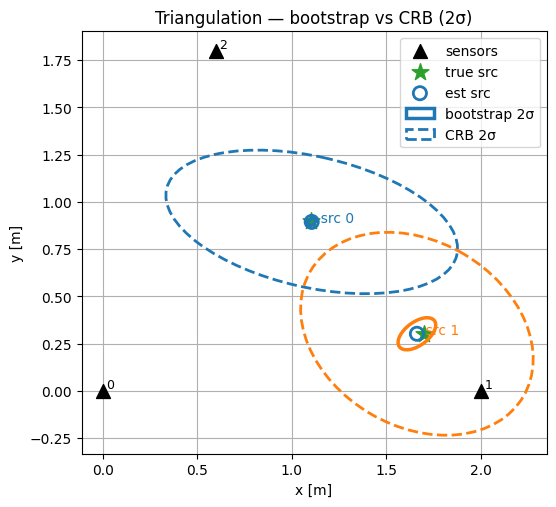

In [9]:

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def cov_ellipse(mu, cov, nsig=2.0, **kw):
    w, v = np.linalg.eigh(cov); w = np.clip(w, 0, None)
    order = np.argsort(w)[::-1]; w, v = w[order], v[:, order]
    width, height = 2*nsig*np.sqrt(w)
    angle = np.degrees(np.arctan2(v[1,0], v[0,0]))
    return Ellipse(xy=mu, width=width, height=height, angle=angle, fill=False, **kw)

fig, ax = plt.subplots(figsize=(6,6))

# sensors
ax.scatter(SENSOR_POS[:,0], SENSOR_POS[:,1], marker='^', s=100, c="k", label="sensors", zorder=2)
for i in range(N): ax.text(SENSOR_POS[i,0], SENSOR_POS[i,1], f" {i}", va='bottom', fontsize=9)

# true & estimated
ax.scatter(TRUE_SRC_POS[:,0], TRUE_SRC_POS[:,1], marker='*', s=160, c="tab:green", label="true src", zorder=3)
ax.scatter(pos_hat[:,0], pos_hat[:,1], facecolors='none', edgecolors="tab:blue",
           marker='o', s=90, linewidths=2, label="est src", zorder=4)

colors = ["tab:blue","tab:orange","tab:red","tab:purple"]
for i in range(K):
    e_boot = cov_ellipse(pos_hat[i], covs[i],     nsig=2.0, edgecolor=colors[i%len(colors)], linewidth=2.5, zorder=5, label="bootstrap 2σ" if i==0 else None)
    ax.add_patch(e_boot)
    if covs_crb[i] is not None:
        e_crb  = cov_ellipse(pos_hat[i], covs_crb[i], nsig=2.0, edgecolor=colors[i%len(colors)], linestyle='--', linewidth=2.0, zorder=5, label="CRB 2σ" if i==0 else None)
        ax.add_patch(e_crb)
    ax.text(pos_hat[i,0], pos_hat[i,1], f"  src {i}", color=colors[i%len(colors)], zorder=6)

ax.set_aspect('equal', 'box')
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title("Triangulation — bootstrap vs CRB (2σ)")
ax.grid(True); ax.legend(loc="best")
plt.show()


## Table: true vs estimated positions, bootstrap & CRB uncertainties

In [10]:

import pandas as pd
from IPython.display import display, HTML

def ellipse_params(cov, nsig=2.0):
    w, v = np.linalg.eigh(cov); idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    a = nsig*np.sqrt(max(w[0], 0.0)); b = nsig*np.sqrt(max(w[1], 0.0))
    ang = np.degrees(np.arctan2(v[1,0], v[0,0]))
    area = np.pi*a*b
    return a, b, ang, area

rows = []
NSIG = 2.0
for i in range(K):
    ab,bb,angb,areab = ellipse_params(covs[i], nsig=NSIG)
    if covs_crb[i] is not None:
        acrb,bcrb,angc,areac = ellipse_params(covs_crb[i], nsig=NSIG)
    else:
        acrb=bcrb=angc=areac=np.nan
    err = float(np.hypot(pos_hat[i,0]-TRUE_SRC_POS[i,0], pos_hat[i,1]-TRUE_SRC_POS[i,1]))
    rows.append(dict(
        source=i,
        true_x=TRUE_SRC_POS[i,0], true_y=TRUE_SRC_POS[i,1],
        est_x=pos_hat[i,0], est_y=pos_hat[i,1],
        err_euclid=err,
        boot_semimajor_m=ab, boot_semiminor_m=bb, boot_angle_deg=angb, boot_area_m2=areab,
        crb_semimajor_m=acrb, crb_semiminor_m=bcrb, crb_angle_deg=angc, crb_area_m2=areac
    ))

df_pos = pd.DataFrame(rows, columns=[
    "source","true_x","true_y","est_x","est_y","err_euclid",
    "boot_semimajor_m","boot_semiminor_m","boot_angle_deg","boot_area_m2",
    "crb_semimajor_m","crb_semiminor_m","crb_angle_deg","crb_area_m2"
])
display(HTML("<h4>Triangulation — True vs Estimated with Bootstrap & CRB (2σ)</h4>"))
display(df_pos.style.format({
    "true_x":"{:.3f}","true_y":"{:.3f}","est_x":"{:.3f}","est_y":"{:.3f}","err_euclid":"{:.3f}",
    "boot_semimajor_m":"{:.4f}","boot_semiminor_m":"{:.4f}","boot_angle_deg":"{:.1f}","boot_area_m2":"{:.6f}",
    "crb_semimajor_m":"{:.4f}","crb_semiminor_m":"{:.4f}","crb_angle_deg":"{:.1f}","crb_area_m2":"{:.6f}"
}))
df_pos.to_csv("triangulation_bootstrap_vs_crb.csv", index=False)
print("Saved -> triangulation_bootstrap_vs_crb.csv")


,source,true_x,true_y,est_x,est_y,err_euclid,boot_semimajor_m,boot_semiminor_m,boot_angle_deg,boot_area_m2,crb_semimajor_m,crb_semiminor_m,crb_angle_deg,crb_area_m2
0,0,1.100,0.900,1.106,0.894,0.009,0.0244,0.0149,-140.6,0.001140,0.7874,0.3456,167.2,0.855069
1,1,1.700,0.300,1.663,0.302,0.037,0.1156,0.0614,-143.3,0.022287,0.6536,0.4893,149.4,1.004686


Saved -> triangulation_bootstrap_vs_crb.csv


## Frequency-only Doppler tables (per sensor and aggregated per source)

In [11]:

import numpy as np
import pandas as pd
from IPython.display import display, HTML

# base (true and estimated) Doppler in Hz
Fbins = model_staged.F.shape[1]
fd_true = unwrap_bins(true_tau_f, Fbins) * float(BIN_HZ)             # (N,K)
fd_est  = unwrap_bins(model_staged.tau_f, Fbins) * float(BIN_HZ)     # (N,K)

# bootstrap uncertainties for fd (Hz)
def reestimate_tau_f_shifts_only(Xb, model_seed, iters_w=20, iters_snap=20):
    m = SpectralShiftNMFkTFGM(
        K=model_seed.K, mode="shifts_only",
        iters_w=iters_w, iters_snap=iters_snap,
        snap_window_f=3, snap_window_t=3,
        ridge_w=0.0, verbose=False
    )
    init = {"F": model_seed.F, "S": model_seed.S, "W": model_seed.W,
            "tau_f": model_seed.tau_f, "tau_t": model_seed.tau_t}
    m.fit(Xb, init=init)
    return m.tau_f

B = 200
rng = np.random.default_rng(123)
base = X_clean if 'X_clean' in globals() else model_staged.reconstruct()
fd_samps = np.zeros((B, N, K))
for b in range(B):
    Xb = add_noise_by_snr_clipped_per_sensor(base, snr_db=SNR_DB, rng=rng)
    tauf_b = reestimate_tau_f_shifts_only(Xb, model_staged)
    fd_samps[b] = unwrap_bins(tauf_b, Fbins) * float(BIN_HZ)
fd_sigma = fd_samps.std(axis=0)   # (N,K)

# per-sensor×source table
rows = []
for n in range(N):
    for k in range(K):
        rows.append(dict(
            sensor=n, source=k,
            fd_true=fd_true[n,k],
            fd_est=fd_est[n,k],
            fd_sigma=fd_sigma[n,k]
        ))
df_fd = pd.DataFrame(rows, columns=["sensor","source","fd_true","fd_est","fd_sigma"])

display(HTML("<h4>Doppler Frequency — True vs Estimated (±1σ)</h4>"))
display(df_fd.style.format({"fd_true":"{:.5f}","fd_est":"{:.5f}","fd_sigma":"{:.5f}"}))

# aggregated per-source (W-weighted)
W = model_staged.W  # (N,K)
rows_src = []
fd_mean_est = np.zeros((K,)); fd_mean_true = np.zeros((K,)); fd_mean_sigma = np.zeros((K,))
for k in range(K):
    w = W[:,k].copy(); w = w / (w.sum() + 1e-12)
    fd_mean_true[k] = float(np.sum(w * fd_true[:,k]))
    fd_mean_est[k]  = float(np.sum(w * fd_est[:,k]))
    fd_mean_samples = np.sum(fd_samps[:,:,k] * w[None,:], axis=1)  # (B,)
    fd_mean_sigma[k] = float(fd_mean_samples.std())
    rows_src.append(dict(source=k, fd_true_mean=fd_mean_true[k], fd_est_mean=fd_mean_est[k], fd_sigma_mean=fd_mean_sigma[k]))
df_fd_src = pd.DataFrame(rows_src, columns=["source","fd_true_mean","fd_est_mean","fd_sigma_mean"])

display(HTML("<h4>Doppler Frequency — Aggregated per Source (W-weighted across sensors)</h4>"))
display(df_fd_src.style.format({"fd_true_mean":"{:.5f}","fd_est_mean":"{:.5f}","fd_sigma_mean":"{:.5f}"}))

# Save CSVs
df_fd.to_csv("doppler_frequency_per_sensor.csv", index=False)
df_fd_src.to_csv("doppler_frequency_per_source.csv", index=False)
print("Saved -> doppler_frequency_per_sensor.csv and doppler_frequency_per_source.csv")


,sensor,source,fd_true,fd_est,fd_sigma
0,0,0,0.31991,0.31897,0.00389
1,0,1,0.68849,0.66641,0.01740
2,1,0,0.13087,0.12822,0.00355
3,1,1,1.30522,1.29748,0.01791
4,2,0,0.94756,0.95129,0.00430
5,2,1,-1.49178,-1.49338,0.00853


,source,fd_true_mean,fd_est_mean,fd_sigma_mean
0,0,0.65695,0.65851,0.00283
1,1,-0.96205,-0.96834,0.00776


Saved -> doppler_frequency_per_sensor.csv and doppler_frequency_per_source.csv
